In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

In [4]:
df = pd.read_csv("Twitter_Data.csv")

print(df.head())

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32004 entries, 0 to 32003
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   clean_text  32003 non-null  object 
 1   category    32003 non-null  float64
dtypes: float64(1), object(1)
memory usage: 500.2+ KB


In [6]:
print(df.isnull().sum())

df.dropna(inplace=True)

X = df["clean_text"]
y = df["category"]

clean_text    1
category      1
dtype: int64


In [7]:
df["Sentiment"] = df["category"].replace({
    -1.0: "Negative",
     0.0: "Neutral",
     1.0: "Positive"
})

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train.fillna(''))
X_test = vectorizer.transform(X_test.fillna(''))

In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8668957975316357
              precision    recall  f1-score   support

        -1.0       0.89      0.72      0.80      1477
         0.0       0.84      0.94      0.89      2180
         1.0       0.88      0.89      0.89      2744

    accuracy                           0.87      6401
   macro avg       0.87      0.85      0.86      6401
weighted avg       0.87      0.87      0.87      6401



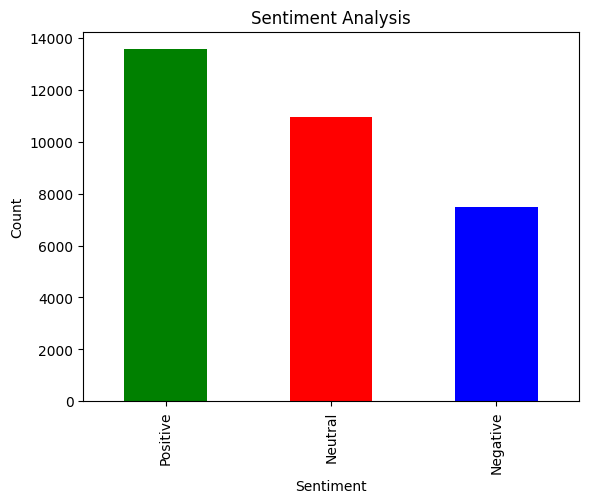

In [11]:
df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["green","red","blue"]
)

plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [13]:
text = " ".join(df["clean_text"])
words = text.split()
counter = Counter(words)
print(counter.most_common(20))

[('modi', 29939), ('the', 20642), ('and', 13705), ('for', 10456), ('you', 8605), ('will', 6445), ('not', 6200), ('this', 5955), ('are', 5949), ('that', 5709), ('india', 5082), ('with', 4384), ('has', 4187), ('have', 4066), ('but', 3716), ('all', 3574), ('from', 3528), ('bjp', 3438), ('his', 3195), ('people', 3029)]


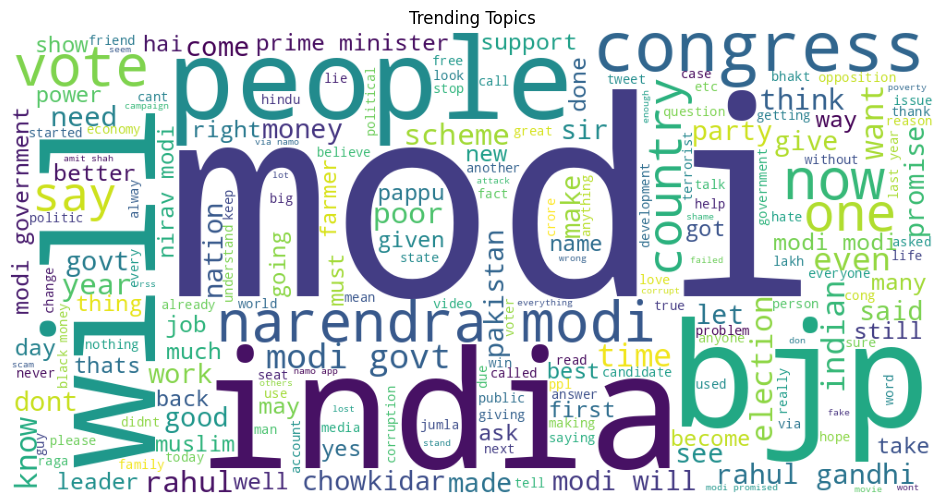

In [14]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Trending Topics")
plt.show()

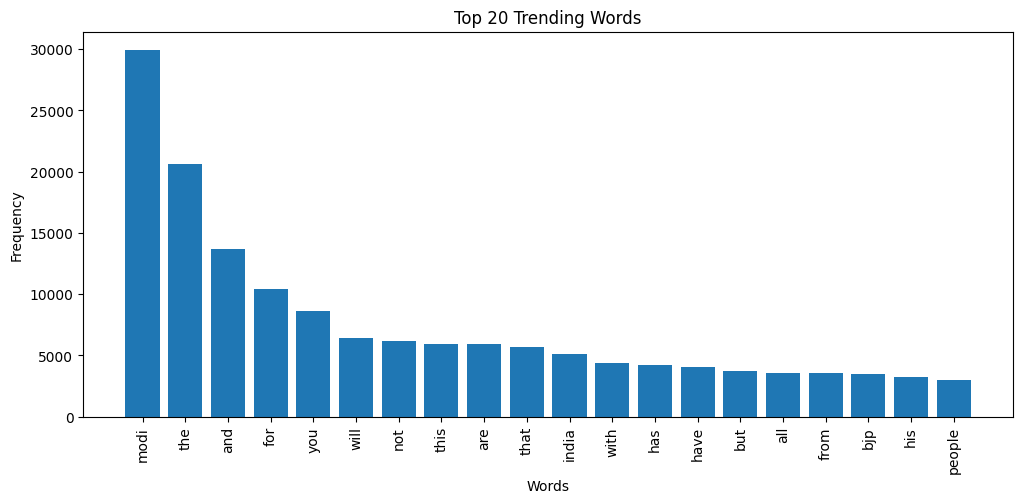

In [15]:
top_words = Counter(words).most_common(20)

word = [i[0] for i in top_words]
count = [i[1] for i in top_words]

plt.figure(figsize=(12,5))
plt.bar(word, count)
plt.xticks(rotation=90)
plt.title("Top 20 Trending Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [16]:
df.to_csv("Social_Media_Sentiment_Output.csv", index=False)

print("Output Saved Successfully")

Output Saved Successfully
